# PSNR vs Compression Ratio — model size × SZ3 error bound  (multi-field)

**Dataset:** NYX 512×512×512.  **Target field:** `baryon_density` (compressed + corrected).  **Aux fields:** the other co-located NYX fields (`dark_matter_density`, `temperature`, `velocity_x/y/z`) are fed to the model as **conditioning inputs** (side information) — they are *not* compressed here and *not* counted in the CR.

**Why sweep the rel-error bound too?**  The model is tiny next to the SZ3 base, so changing the parameter count alone moves the total CR only a little.  The knob that actually moves CR is the **SZ3 relative-error bound** — looser bound → smaller SZ3 stream → higher CR but lower base PSNR.

So we sweep `rel_err` (spreads CR along x) **and** a range of model sizes (separate curves).  Per point:

```
CR = original_target_bytes / (sz_bytes(rel_err) + n_params * 2)   # params stored as bf16
```

Note: NYX's SZ3 stream is small (sub-MB at loose bounds), so the model-byte overhead is **not** negligible — that's exactly why parameter count matters here.  Aux fields give the model extra cross-field structure to exploit when correcting the target.

Result: a family of rate–distortion curves — one per model size — plus the SZ3-only baseline.

In [1]:
import random, sys, os, copy, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")

# Force-reload edited modules so re-running this cell picks up bg_stage.py changes
# WITHOUT restarting the kernel (Jupyter caches modules in sys.modules).
import importlib
import bg_stage
importlib.reload(bg_stage)

from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
from bg_shard import pick_bg_h_under_budget

pysz_dir = "/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_dir not in sys.path:
    sys.path.append(pysz_dir)
from pysz import SZ

def set_seed(seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPUs: {torch.cuda.device_count()}")

Device: cuda:0 | GPUs: 1


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
halo_finder_root = Path("/home/sam/Halo_Finder")
nyx_dir     = halo_finder_root / "halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin"
sz_lib_path = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"

# Target field = the one we SZ3-compress and then correct with the model.
TARGET_FIELD = "baryon_density"
# Aux fields = fed to the model as conditioning inputs (side info; not in CR).
AUX_FIELDS   = ["dark_matter_density", "temperature",
                "velocity_x", "velocity_y", "velocity_z"]

FIELD_PATHS = {f: (nyx_dir / f"{f}.f32").as_posix()
               for f in [TARGET_FIELD] + AUX_FIELDS}
raw_path    = FIELD_PATHS[TARGET_FIELD]

# ── Dataset constants ──────────────────────────────────────────────────────────
data_shape  = (512, 512, 512)
TARGET_STEM = f"nyx_{TARGET_FIELD}"

# Quick-test downsample: stride>1 shrinks every field (and re-compresses the
# target) so the whole sweep runs fast.  CR is then computed on the shrunk cube
# — still a valid R-D curve, just lower resolution.  Set to 1 for full-res.
SPATIAL_STRIDE = 1

sz_engine = SZ(sz_lib_path)
print(f"SZ engine loaded | target={TARGET_FIELD} | aux={AUX_FIELDS}")

SZ engine loaded | target=baryon_density | aux=['dark_matter_density', 'temperature', 'velocity_x', 'velocity_y', 'velocity_z']


In [3]:
def _load_field(name, stride=1):
    """Load one NYX field as float32 (optionally strided)."""
    vol = np.fromfile(FIELD_PATHS[name], dtype=np.float32).reshape(data_shape)
    if stride > 1:
        vol = np.ascontiguousarray(vol[::stride, ::stride, ::stride])
    return vol

def load_gt(stride=1):
    """Ground-truth TARGET field."""
    return _load_field(TARGET_FIELD, stride)

def compress_at(vol, rel_err):
    """SZ3-compress the TARGET field at a rel-error bound, then build the
    multi-field model input: [SZ3-decompressed target] + full-precision aux.
    Returns (Xps_list, sz_bytes, sz_cr).  Only the target stream is counted."""
    b, cr = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq  = sz_engine.decompress(b, vol.shape, np.float32).astype(np.float32)
    return [np.asarray(x_lq, np.float32)] + aux_fields, int(len(b)), float(cr)

In [4]:
t0 = time.time()
gt         = load_gt(SPATIAL_STRIDE)                       # target (corrected)
aux_fields = [_load_field(f, SPATIAL_STRIDE) for f in AUX_FIELDS]   # conditioning
Xs         = [gt] + aux_fields                             # field 0 = target
work_shape = gt.shape
orig_bytes = gt.nbytes                                     # CR is for target only

def psnr_from_arrays(target, recon):
    data_range = float(target.max() - target.min())
    if data_range <= 0:
        data_range = 1.0
    mse = float(np.mean((target - recon) ** 2))
    return 100.0 if mse <= 0 else 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

print(f"Loaded target + {len(aux_fields)} aux in {time.time()-t0:.1f}s | "
      f"shape {work_shape} (stride={SPATIAL_STRIDE}) | target {orig_bytes/1e6:.1f} MB")
print(f"  fields (model input order): {[TARGET_FIELD] + AUX_FIELDS}")

Loaded target + 5 aux in 0.5s | shape (512, 512, 512) (stride=1) | target 536.9 MB
  fields (model input order): ['baryon_density', 'dark_matter_density', 'temperature', 'velocity_x', 'velocity_y', 'velocity_z']


In [5]:
def build_cfg(Xs_in, Xps_in, max_train_time, bg_h, steps_per_epoch,
              lr=1e-4, epochs=20, log_prefix="", patch_size=None):
    if patch_size is None:
        patch_size = Xs_in[0].shape[2]
    cfg = build_bg_only_cfg(
        X_target=Xs_in[0], Xps=Xps_in, max_train_time=max_train_time,
        epochs=epochs, steps_per_epoch=steps_per_epoch, bg_h=bg_h,
        bg_batch=1, bg_patch_size=patch_size, lr=lr,
    )
    cfg.bg_sample_mode   = "sequential"
    cfg.bg_log_prefix    = log_prefix
    cfg.bg_arch          = "spatial"
    cfg.amp              = True
    cfg.amp_dtype        = "bf16"
    cfg.bg_ddp           = False
    cfg.bg_data_parallel = False
    return cfg

def n_params_of(model):
    return int(sum(p.numel() for p in unwrap_bg_model(model).parameters()))

print("Helpers ready")

Helpers ready


## Sweep:  rel-error bound  ×  model size

Outer loop = `REL_ERRS` (each value re-compresses the cube with SZ3 → a new base CR / base PSNR).  Inner loop = `PARAM_TARGETS` (each mapped to a `bg_h` via `pick_bg_h_under_budget`).  `lr` is fixed; each model trains for `TIME_PER_CONFIG` s for the full budget (no early-stop — fair ablation).

**Total trainings = len(REL_ERRS) × #distinct model sizes** — keep both lists short for full-res 1024³, or use `SPATIAL_STRIDE>1` first to smoke-test the shape of the curves.

In [6]:
# ── Fixed knobs ───────────────────────────────────────────────────────────────
FIXED_LR        = 1e-3
TIME_PER_CONFIG = 60        # wall-clock budget per model (early-stop may end sooner)
BYTES_PER_PARAM = 2             # bf16 storage for the model weights
FREQ_WARMUP     = 1            # epochs before the FFT/freq loss term joins the loss

# Outer sweep: SZ3 relative-error bound (this is what actually moves CR).
# NYX compresses very well, so these bounds span a wide CR range; adjust freely.
REL_ERRS = [1e-6, 3e-6, 5e-6, 7e-6, 9e-6]

# Inner sweep: model parameter budgets (separate curves)
PARAM_TARGETS = [3000, 6000, 9000, 15000, 25000, 30000, 60000, 90000]
H_CANDIDATES  = list(range(3, 100))

# Map each budget -> largest bg_h that fits, for the MULTI-FIELD input
# (n_fields = target + aux); dedupe (several budgets may share a bg_h).
N_FIELDS = len(Xs)
_seen = set()
sweep_plan = []          # list of (bg_h, est_params)
for tgt in PARAM_TARGETS:
    h, est_p = pick_bg_h_under_budget(
        tgt, shape=work_shape, n_fields=N_FIELDS,
        bg_arch="spatial", h_candidates=H_CANDIDATES,
    )
    if h not in _seen:
        _seen.add(h)
        sweep_plan.append((int(h), int(est_p)))
sweep_plan.sort()

n_runs = len(REL_ERRS) * len(sweep_plan)
print(f"Fixed: lr={FIXED_LR:.1e} | n_fields={N_FIELDS} | {TIME_PER_CONFIG:.0f}s/config | "
      f"freq_warmup={FREQ_WARMUP}")
print(f"REL_ERRS: {REL_ERRS}")
print(f"Model sizes ({len(sweep_plan)} distinct):")
for h, est_p in sweep_plan:
    print(f"  bg_h={h:2d}  ~{est_p:,} params")
print(f"\n>> {n_runs} trainings total (~{n_runs*TIME_PER_CONFIG/60:.0f} min "
      f"at {TIME_PER_CONFIG:.0f}s each)")


[Model: spatial] Total Params: 859
 [Params] Main (BG) Network : 859 parameters

[Model: spatial] Total Params: 1,396
 [Params] Main (BG) Network : 1,396 parameters

[Model: spatial] Total Params: 2,059
 [Params] Main (BG) Network : 2,059 parameters

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters

[Model: spatial] Total Params: 4,804
 [Params] Main (BG) Network : 4,804 parameters

[Model: spatial] Total Params: 5,971
 [Params] Main (BG) Network : 5,971 parameters

[Model: spatial] Total Params: 7,264
 [Params] Main (BG) Network : 7,264 parameters

[Model: spatial] Total Params: 8,683
 [Params] Main (BG) Network : 8,683 parameters

[Model: spatial] Total Params: 10,228
 [Params] Main (BG) Network : 10,228 parameters

[Model: spatial] Total Params: 11,899
 [Params] Main (BG) Network : 11,899 parameters

[Model: spatial] Total Params: 13,696
 [Params] Main (BG) Networ

In [7]:
# Reload bg_stage so re-running ONLY this cell picks up early-stop edits.
import importlib, bg_stage
importlib.reload(bg_stage)
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
print(f"bg_stage OK: {bg_stage.__file__}\n")

depth    = work_shape[0]
patch_sz = work_shape[2]

# GPU warm-up (not timed) using the loosest rel_err
_w_Xps, _, _ = compress_at(gt, max(REL_ERRS))
_wcfg = build_cfg(Xs, _w_Xps, max_train_time=0.5, bg_h=4,
                  steps_per_epoch=2, lr=1e-3, epochs=1, log_prefix="warmup")
set_seed(42)
train_bg_only(Xs=Xs, Xps=_w_Xps, device=device, cfg=_wcfg,
              evaluator=lambda m, c=_wcfg: (0.0, 0.0))
torch.cuda.synchronize() if torch.cuda.is_available() else None
del _w_Xps
print("GPU warm-up done\n")

results   = []   # dict: rel, bg_h, n_params, psnr, cr, model_mb, sz_mb, epochs
baselines = []   # dict: rel, cr, psnr, sz_mb   (SZ3 only, no model)

sweep_t0 = time.time()
for rel in REL_ERRS:
    Xps_list, sz_bytes, sz_cr = compress_at(gt, rel)
    base_psnr = psnr_from_arrays(gt, Xps_list[0])
    base_cr   = orig_bytes / sz_bytes
    baselines.append(dict(rel=rel, cr=base_cr, psnr=base_psnr, sz_mb=sz_bytes/1e6))
    print(f"\n{'#'*60}")
    print(f"# rel={rel:.0e} | SZ3 base: CR={base_cr:.2f}x ({sz_bytes/1e6:.2f} MB) | "
          f"base PSNR={base_psnr:.2f} dB")

    for bg_h, est_p in sweep_plan:
        cfg = build_cfg(Xs, Xps_list, max_train_time=1e9, bg_h=bg_h,
                        steps_per_epoch=depth, lr=FIXED_LR, epochs=20,
                        log_prefix=f"r{rel:.0e}-h{bg_h}", patch_size=patch_sz)
        cfg.bg_early_stop          = False   # ablation: train every model the full budget
        cfg.bg_freq_warmup_epochs  = FREQ_WARMUP

        def evaluator(m, c=cfg, Xp=Xps_list):
            xh = run_bg_inference(unwrap_bg_model(m), Xs, Xp, c, rel)
            return psnr_from_arrays(gt, xh), 0.0

        set_seed(42)
        model, hist = train_bg_only(Xs=Xs, Xps=Xps_list, device=device,
                                    cfg=cfg, evaluator=evaluator)

        n_params    = n_params_of(model)
        psnr_vals   = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
        psnr        = max(psnr_vals) if psnr_vals else float("nan")
        model_bytes = n_params * BYTES_PER_PARAM
        cr          = orig_bytes / (sz_bytes + model_bytes)
        results.append(dict(rel=rel, bg_h=bg_h, n_params=n_params, psnr=psnr, cr=cr,
                            model_mb=model_bytes/1e6, sz_mb=sz_bytes/1e6,
                            epochs=len(hist.get("loss", []))))
        print(f"  bg_h={bg_h:2d} ({n_params:,}p): PSNR={psnr:.2f} dB | CR={cr:.2f}x "
              f"(base {base_cr:.2f}x) | +{psnr-base_psnr:.2f} dB over SZ3")
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    del Xps_list

print(f"\n--- Sweep complete in {(time.time()-sweep_t0)/60:.1f} min "
      f"({len(results)} models over {len(REL_ERRS)} rel-errors) ---")

bg_stage OK: /home/sam/Halo_Finder/Final_design/base_script/bg_stage.py



KeyboardInterrupt: 

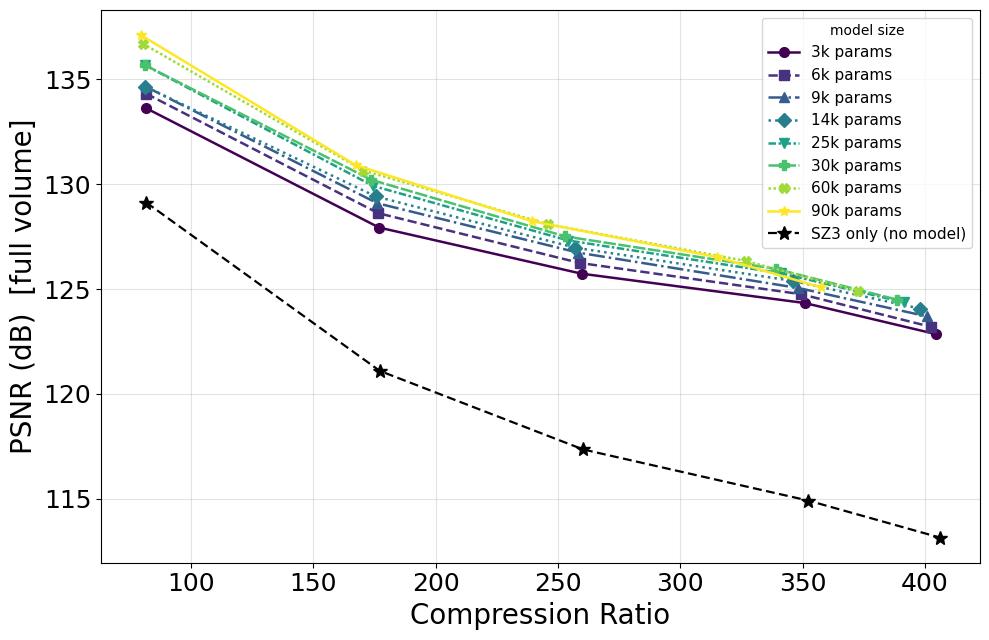

Saved: psnr_vs_cr_relsweep_nyx_baryon_density.pdf

    rel  bg_h     params  PSNR(dB)       CR   baseCR     +dB  epochs
  1e-06     6      2,848    133.63    81.76    81.83    4.50      20
  1e-06     9      5,971    134.33    81.68    81.83    5.20      20
  1e-06    11      8,683    134.66    81.61    81.83    5.53      20
  1e-06    14     13,696    134.66    81.49    81.83    5.53      20
  1e-06    19     24,571    135.69    81.22    81.83    6.56      20
  1e-06    21     29,803    135.70    81.09    81.83    6.57      20
  1e-06    30     59,584    136.71    80.37    81.83    7.59      20
  1e-06    37     89,803    137.12    79.65    81.83    7.99      20
  3e-06     6      2,848    127.94   176.90   177.23    6.84      20
  3e-06     9      5,971    128.62   176.53   177.23    7.53      20
  3e-06    11      8,683    129.09   176.22   177.23    8.00      20
  3e-06    14     13,696    129.42   175.64   177.23    8.32      20
  3e-06    19     24,571    129.92   174.40   177.23

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

# One curve per model size; points span the rel_err sweep (-> CR axis)
param_sizes = sorted(set(r["n_params"] for r in results))
cmap = plt.cm.viridis
colors = {p: cmap(i / max(1, len(param_sizes) - 1)) for i, p in enumerate(param_sizes)}

# Distinct marker shape + line style per curve (cycled if there are more curves)
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]

def fmt_p(p):
    return f"{p/1000:.0f}k" if p >= 1000 else str(p)

for i, p in enumerate(param_sizes):
    pts = sorted([r for r in results if r["n_params"] == p], key=lambda r: r["cr"])
    ax.plot([r["cr"] for r in pts], [r["psnr"] for r in pts],
            marker=MARKERS[i % len(MARKERS)],
            linestyle=LINESTYLES[i % len(LINESTYLES)],
            color=colors[p], markersize=7, linewidth=1.8, zorder=3,
            label=f"{fmt_p(p)} params")

# SZ3-only baseline curve
bl = sorted(baselines, key=lambda b: b["cr"])
ax.plot([b["cr"] for b in bl], [b["psnr"] for b in bl],
        marker="*", linestyle=(0, (4, 2)), color="black",
        markersize=10, linewidth=1.6, zorder=2,
        label="SZ3 only (no model)")
# Annotate baseline points with their rel_err
# for b in bl:
#     ax.annotate(f"{b['rel']:.0e}", xy=(b["cr"], b["psnr"]),
#                 xytext=(0, -14), textcoords="offset points",
#                 ha="center", fontsize=7, color="black")

ax.set_xlabel("Compression Ratio", fontsize = 20)
ax.set_ylabel("PSNR (dB)  [full volume]",fontsize = 20)
ax.tick_params(axis='both', which='major', labelsize=18)
# ax.set_title(
#     f"PSNR vs CR — NYX {work_shape} (stride={SPATIAL_STRIDE})\n"
#     f"rel_err {min(REL_ERRS):.0e}–{max(REL_ERRS):.0e} (labels) · lr={FIXED_LR:.0e} · "
#     f"{TIME_PER_CONFIG:.0f}s/config · curves = model size"
# )
ax.grid(True, alpha=0.35)
ax.legend(loc="best", fontsize=11, title="model size")
plt.tight_layout()
out_png = f"psnr_vs_cr_relsweep_{TARGET_STEM}.pdf"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

# Full table to stdout so every (rel, params) value is visible
print(f"\n{'rel':>7} {'bg_h':>5} {'params':>10} {'PSNR(dB)':>9} {'CR':>8} "
      f"{'baseCR':>8} {'+dB':>7} {'epochs':>7}")
base_by_rel = {b['rel']: b for b in baselines}
for r in sorted(results, key=lambda r: (r['rel'], r['n_params'])):
    b = base_by_rel[r['rel']]
    print(f"{r['rel']:>7.0e} {r['bg_h']:>5} {r['n_params']:>10,} {r['psnr']:>9.2f} "
          f"{r['cr']:>8.2f} {b['cr']:>8.2f} {r['psnr']-b['psnr']:>7.2f} {r['epochs']:>7}")